#### **Advanced use of recurrent neural networks**

In this notebook, we'll review three advanced techniques for improving the performance and generalization power of recurrent neural networks and apply them on a temperature-forecasting problem. Let's get started.

#### **A temperature-forecasting problem**

This is a weather timeseries dataset recorded at the Weather Station at the Max Plank Institute for Biogeochemistry in Jena, Germany. --- Olaf Kolle: www.bgc-jena.mpg.de/wetter

In [1]:
%mkdir jena_climate
%cd jena_climate/
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

/home/abanerjee/Downloads/jena_climate
--2026-06-15 13:34:21--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.207.16, 52.217.230.64, 16.15.245.52, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.207.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12,94M  7,86MB/s    in 1,6s    

2026-06-15 13:34:23 (7,86 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In this dataset, 14 different quamtities (such air temparature, atmospheric pressure, humidity, wind direction, and so on) were recored every 10 minutes, over several years.

#### **Let's look at the data**

In [3]:
### Inspeacting the data of the Jena weather dataset
import os


fname = '/home/abanerjee/Downloads/jena_climate/jena_climate_2009_2016.csv'

f = open(fname)
data = f.read()
f.close()

lines = data.split('\n')
header = lines[0].split(',')
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


Now, convert all 420,551 lines of data into a Numpy array.

In [4]:
### Parsing the data
import numpy as np

float_data = np.zeros((len(lines), len(header) -1))
for i, line in enumerate(lines):
  values = [float(x) for x in line.split(',')[1:]]
  float_data[i, :] = values

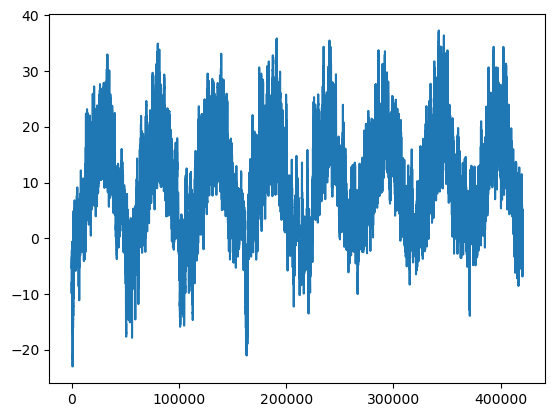

In [5]:
### Plotting the temparature timeseries
from matplotlib import pyplot as plt

temp = float_data[:, 1]
plt.plot(range(len(temp)), temp)

We can clearly see the yearly periodicity of the temperature. We can make a more narrower plot of the first 10 days. As the data is recored every 10 minutes, you get 144 data points per day.

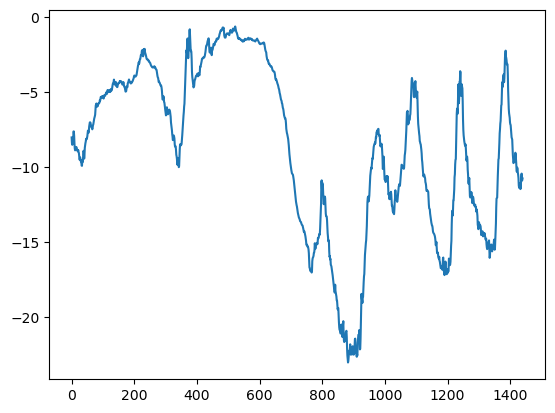

In [6]:
### Plotting the first 10 days of the temperature timeseries
plt.plot(range(1440), temp[:1440])

We can see a daily periodicity, especially evident for the last 4 days. Also note that, this 10-day period must be coming from a fairly cold winter month.

Question: Is this timeseries predictable at a daily scale? Let's find out.

#### **Preparing the data**

**Problem formulation:** Given data going as far back as `lookback`  timesteps (How many timesteps back the input data should go, a timestep is 10 minutes) and sampled every `steps` timesteps, can we predict the temperature in `delay` timesteps (How many timesteps in the future the target should be)?

In [7]:
### Normalizing the data (As the temperature in degree celcius but pressure in 1000mbar)

mean = float_data[:200000].mean(axis = 0)
float_data -= mean
std = float_data[:200000].std(axis=0)
float_data /= std

In [8]:
### Generator yielding timeseries samples and their targets

def generator(data, lookback, delay, min_index, max_index, shuffle=False, batch_size=128, step=6):
  if max_index is None:
    max_index = len(data) - delay - 1
  i = min_index + lookback

  while 1:
    if shuffle:
      rows = np.random.randint(min_index + lookback, max_index, size=batch_size)
    else:
      if i + batch_size >= max_index:
        i = min_index + lookback
      rows = np.arange(i, min(i + batch_size, max_index))
      i += len(rows)
    samples = np.zeros((len(rows), lookback // step, data.shape[-1]))
    targets = np.zeros((len(rows),))

    for j, row in enumerate(rows):
      indices = range(rows[j] - lookback, rows[j], step)
      samples[j] = data[indices]
      targets[j] = data[rows[j] + delay][1]

    yield samples, targets #pauses the function's execution and returns a value temporarily

In [9]:
### Preparing the training, validation, and test generators

lookback = 1440
step = 6 #1 hour
delay = 144 # one day
batch_size = 64

train_gen = generator(float_data, lookback=lookback, delay=delay, min_index=0, max_index=200000,
                      shuffle = True, step = step, batch_size = batch_size)

val_gen = generator(float_data, lookback=lookback, delay=delay, min_index=200001, max_index=300000,
                    step=step, batch_size=batch_size)

test_gen = generator(float_data, lookback=lookback, delay=delay, min_index=300001, max_index=None,
                     step = step, batch_size=batch_size)

val_steps = (300000 - 200001 - lookback)
test_steps = (len(float_data) - 300001 - lookback)

#### **Non Maching Learning Baseline**

The temperature timeseries can safely be assumed to be continuous (the temperatures tomorrow are likely to be close to the temperatures today) as well as periodical with a daily period. Thus we can simply predict the tomorrow's temprature will be equal to the temperature right now. Let's evaluate.

In [10]:
### Evaluation Metric: Mean Absolute Error (MAE)

def evaluate_naive_method():
  batch_maes = []
  for step in range(val_steps):
    samples, targets = next(val_gen)
    preds = samples[:, -1, 1]
    mae = np.mean(np.abs(preds - targets))
    batch_maes.append(mae)

  print(np.mean(batch_maes))

evaluate_naive_method()

0.2896754378827307


This is a normalize value. Let's translate it to a Celsius error.

In [11]:
### Converting the MAE back to a Celsius error
celsius_mae = 0.29 * std[1]
print(celsius_mae)

2.5672247338393395


The deviation is not that much. So we can consider it as a baseline. Now we need to reduce this error with machine learning...

#### **A basic machine learning approach**

Two hidden layer based small MLP.

In [12]:
### Training and Evaluating MLP

from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

with tf.device('/GPU:0'):
    model = Sequential([
        layers.Flatten(input_shape=(lookback // step, float_data.shape[-1])),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=RMSprop(),
        loss='mae'
    )
history = model.fit(train_gen, steps_per_epoch=500, epochs = 20,
                              validation_data=val_gen, validation_steps = val_steps)

2026-06-15 13:38:41.194489: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-15 13:38:41.194511: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


TensorFlow version: 2.9.1
GPUs: []


2026-06-15 13:38:43.708640: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-15 13:38:43.708781: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-06-15 13:38:43.708880: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-06-15 13:38:43.708956: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcufft.so.10'; dlerror: libcufft.so.10: cannot open shared object file: No such file or directory
2026-06-15 13:38:43.930172: W tensorflow/stream_executor/platform/default/dso_loader.cc:64

Epoch 1/20
500/500 [==============================] - 335s 670ms/step - loss: 1.7349 - val_loss: 0.7906
Epoch 2/20
500/500 [==============================] - 339s 679ms/step - loss: 0.6602 - val_loss: 0.4001
Epoch 3/20
500/500 [==============================] - 342s 686ms/step - loss: 0.3346 - val_loss: 0.3049
Epoch 4/20
500/500 [==============================] - 344s 689ms/step - loss: 0.2802 - val_loss: 0.3085
Epoch 5/20
500/500 [==============================] - 311s 622ms/step - loss: 0.2638 - val_loss: 0.3089
Epoch 6/20
500/500 [==============================] - 306s 614ms/step - loss: 0.2575 - val_loss: 0.3383
Epoch 7/20
500/500 [==============================] - 309s 619ms/step - loss: 0.2503 - val_loss: 0.3074
Epoch 8/20
500/500 [==============================] - 302s 605ms/step - loss: 0.2427 - val_loss: 0.3122
Epoch 9/20
500/500 [==============================] - 299s 599ms/step - loss: 0.2399 - val_loss: 0.3260
Epoch 10/20
500/500 [==============================] - 305s 611m

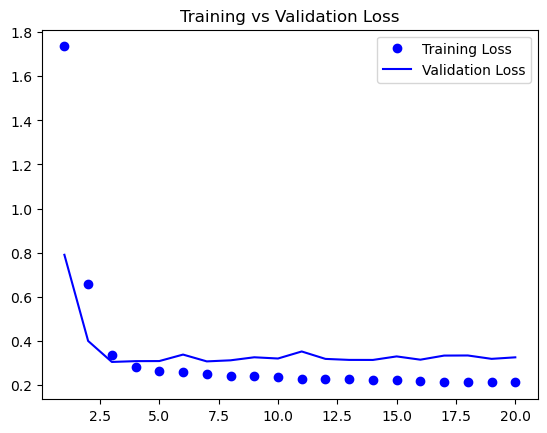

In [13]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 21)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

A simple two layer MLP give a tough baseline to outperform. But can we improve. The model is super slow during the validation stage.

#### **A first recurrent baseline: GRU**

Why GRU and why not LSTM?

GRU layers work using the same principle as LSTM, but they're somewhat streamlined and thus cheaper to run (although they may not have as much representational power as LSTM). https://arxiv.org/abs/1412.3555

In [14]:
### Training and evaluating a GRU-based model

from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.GRU(32, input_shape=(None, float_data.shape[-1])))
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(train_gen,
                    steps_per_epoch=500,
                    epochs=20,
                    validation_data=val_gen,
                    validation_steps = val_steps)

Epoch 1/20
500/500 [==============================] - 1587s 3s/step - loss: 0.3025 - val_loss: 0.2733
Epoch 2/20
500/500 [==============================] - 1539s 3s/step - loss: 0.2876 - val_loss: 0.2738
Epoch 3/20
500/500 [==============================] - 1552s 3s/step - loss: 0.2826 - val_loss: 0.2737
Epoch 4/20
500/500 [==============================] - 1592s 3s/step - loss: 0.2756 - val_loss: 0.2710
Epoch 5/20
500/500 [==============================] - 90883s 182s/step - loss: 0.2705 - val_loss: 0.2653
Epoch 6/20
500/500 [==============================] - 1599s 3s/step - loss: 0.2690 - val_loss: 0.2651
Epoch 7/20
500/500 [==============================] - 1583s 3s/step - loss: 0.2671 - val_loss: 0.2633
Epoch 8/20
500/500 [==============================] - 1579s 3s/step - loss: 0.2600 - val_loss: 0.2635
Epoch 9/20
500/500 [==============================] - 1560s 3s/step - loss: 0.2574 - val_loss: 0.2644
Epoch 10/20
500/500 [==============================] - 1543s 3s/step - loss: 0.

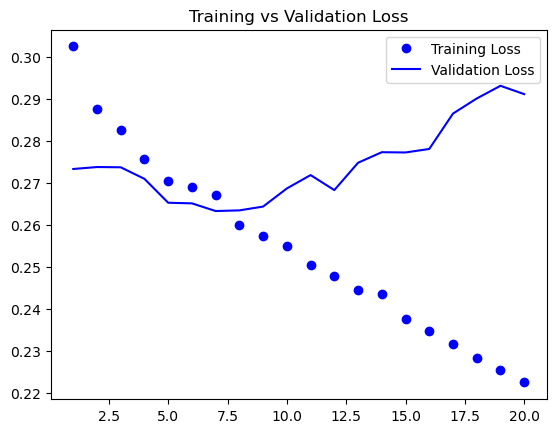

In [15]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 21)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

The training and validation losses start to diverge considerably after a few epochs.. Let's get rid of this step by step.

#### **Using recurrent dropout to fight overfitting**

Let’s add dropout and recurrent dropout to the GRU layer and see how doing so impacts overfitting. Because networks being regularized with dropout always take longer to fully converge, you’ll train the network for twice as many epochs.

In [16]:
#### Training and evaluating a dropout-regualirzed GRU-based model

from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.GRU(32, dropout=0.2, recurrent_dropout=0.2, input_shape=(None, float_data.shape[-1])))
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(train_gen,
                    steps_per_epoch=500,
                    epochs=20,
                    validation_data=val_gen,
                    validation_steps = val_steps)

Epoch 1/20
500/500 [==============================] - 2223s 4s/step - loss: 0.3260 - val_loss: 0.2818
Epoch 2/20
500/500 [==============================] - 2226s 4s/step - loss: 0.3085 - val_loss: 0.2775
Epoch 3/20
500/500 [==============================] - 2223s 4s/step - loss: 0.3030 - val_loss: 0.2751
Epoch 4/20
500/500 [==============================] - 2225s 4s/step - loss: 0.3011 - val_loss: 0.2769
Epoch 5/20
500/500 [==============================] - 2225s 4s/step - loss: 0.2987 - val_loss: 0.2790
Epoch 6/20
500/500 [==============================] - 2224s 4s/step - loss: 0.2934 - val_loss: 0.2775
Epoch 7/20
500/500 [==============================] - 2224s 4s/step - loss: 0.2903 - val_loss: 0.2734
Epoch 8/20
500/500 [==============================] - 2225s 4s/step - loss: 0.2862 - val_loss: 0.2733
Epoch 9/20
500/500 [==============================] - 2226s 4s/step - loss: 0.2852 - val_loss: 0.2758
Epoch 10/20
500/500 [==============================] - 2226s 4s/step - loss: 0.283

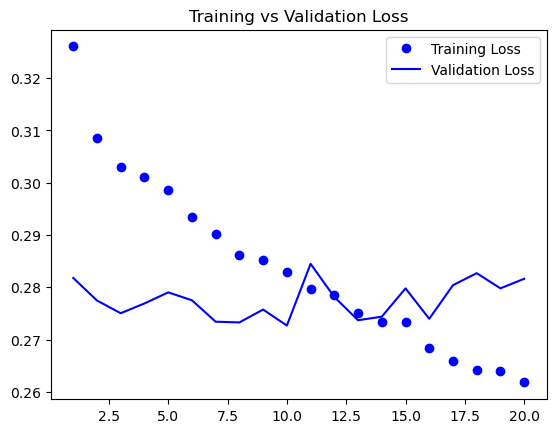

In [17]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 21)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

#### **Stacking Recurrent Layers**

We are no longer overfitting but seem to have hit a performance bottleneck, we should consider increasing the capacity of the network.

Increasing network capacity is typically done by increasing the number of units in the layers or adding more layers. Recurrent layer stacking is a classic way to build more-powerful recurrent networks: for instance, what currently powers the Google Translate algorithm is a stack of seven large LSTM layers---that's huge.

In [18]:
### Training and evaluating a dropout-regularized, stacked GRU model

from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.GRU(32, dropout=0.1, recurrent_dropout=0.5, return_sequences=True, input_shape=(None, float_data.shape[-1])))
model.add(layers.GRU(64, activation='relu', dropout=0.1, recurrent_dropout=0.5))
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(train_gen,
                    steps_per_epoch=500,
                    epochs=20,
                    validation_data=val_gen,
                    validation_steps = val_steps)

Epoch 1/20
500/500 [==============================] - 4426s 9s/step - loss: 0.3282 - val_loss: 0.2879
Epoch 2/20
500/500 [==============================] - 4452s 9s/step - loss: 0.3067 - val_loss: 0.2807
Epoch 3/20
500/500 [==============================] - 4479s 9s/step - loss: 0.3013 - val_loss: 0.2821
Epoch 4/20
500/500 [==============================] - 4390s 9s/step - loss: 0.2967 - val_loss: 0.2750
Epoch 5/20
500/500 [==============================] - 4386s 9s/step - loss: 0.2914 - val_loss: 0.2695
Epoch 6/20
500/500 [==============================] - 4389s 9s/step - loss: 0.2852 - val_loss: 0.2834
Epoch 7/20
500/500 [==============================] - 4390s 9s/step - loss: 0.2793 - val_loss: 0.2735
Epoch 8/20
500/500 [==============================] - 4383s 9s/step - loss: 0.2757 - val_loss: 0.2780
Epoch 9/20
500/500 [==============================] - 4390s 9s/step - loss: 0.2716 - val_loss: 0.2851
Epoch 10/20
500/500 [==============================] - 4382s 9s/step - loss: 0.266

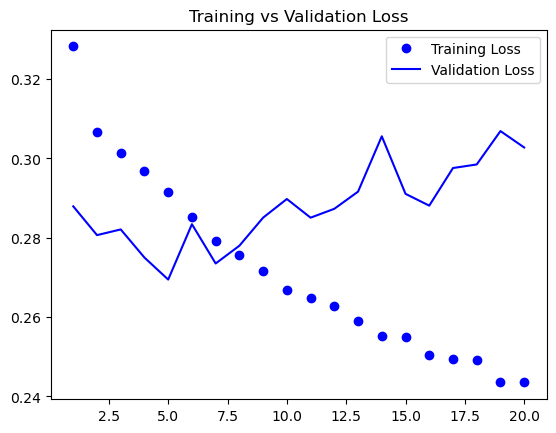

In [19]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 21)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

Adding a layer didn't help by a significant factor, so we may be seeing diminishing returns from increasing network capacity at this point.

#### **Using bidirectional RNNs**

A bidirectional RNN exploits the order sensitivity of RNNs: it consists of using two regular RNNs, such as the GRU and LSTM layers, each of which processes the input sequence in one direction (chronologically and antichronologically), and then merging their representations.

In [21]:
### Could the RNNs have performed well enough if they processed input sequences in antichronological order? Let's find out by reversing the order of the input sequences and training a new model on this reversed data.
### Training and evaluating an LSTM using reversed sequences

from keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from keras import layers
from keras.models import Sequential

max_features = 10000 # Number of words to consider as features
maxlen = 500 # Cuts off texts after this number of words (among the max_features most common words)

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features) # loads data
X_train = [x[::-1] for x in X_train] # reverses the input sequences
X_test = [x[::-1] for x in X_test] # reverses the input sequences

X_train = sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = sequence.pad_sequences(X_test, maxlen=maxlen)

model = Sequential()
model.add(layers.Embedding(max_features, 128, input_length=maxlen))
model.add(layers.LSTM(32))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train, epochs=20, batch_size=128,
                    validation_split=0.2)

Epoch 1/20
157/157 [==============================] - 39s 234ms/step - loss: 0.4824 - acc: 0.7720 - val_loss: 0.3516 - val_acc: 0.8634
Epoch 2/20
157/157 [==============================] - 36s 232ms/step - loss: 0.3086 - acc: 0.8835 - val_loss: 0.2994 - val_acc: 0.8870
Epoch 3/20
157/157 [==============================] - 38s 242ms/step - loss: 0.2549 - acc: 0.9067 - val_loss: 0.3243 - val_acc: 0.8762
Epoch 4/20
157/157 [==============================] - 38s 244ms/step - loss: 0.2087 - acc: 0.9265 - val_loss: 0.6375 - val_acc: 0.7882
Epoch 5/20
157/157 [==============================] - 37s 234ms/step - loss: 0.1904 - acc: 0.9315 - val_loss: 0.3182 - val_acc: 0.8768
Epoch 6/20
157/157 [==============================] - 38s 239ms/step - loss: 0.1651 - acc: 0.9429 - val_loss: 0.4338 - val_acc: 0.8550
Epoch 7/20
157/157 [==============================] - 37s 235ms/step - loss: 0.1583 - acc: 0.9459 - val_loss: 0.3553 - val_acc: 0.8748
Epoch 8/20
157/157 [==============================] - 3

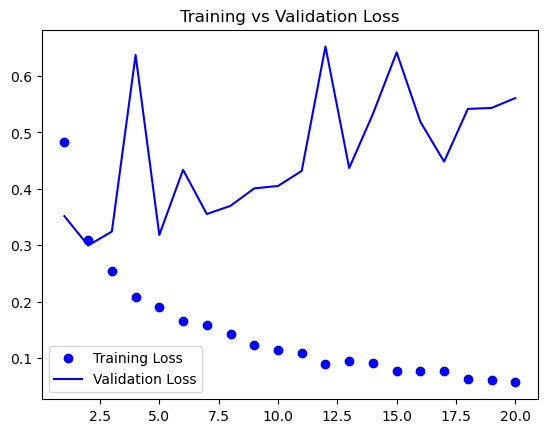

In [ ]:

val_loss = history.history['val_loss']

epochs = range(1, 21)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

Representations that are different yet useful are always worth exploiting, and they more they differ, the better: they offer a new angle from which to look at your data, capturing aspects of the data that were missed by other approaches, and thus they can help boost performance on a task.

In [23]:
### Training and evaluating a bidirectional LSTM on IMDB dataset
from keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from keras import layers
from keras.models import Sequential

model = Sequential()
model.add(layers.Embedding(max_features, 32))
model.add(layers.Bidirectional(layers.LSTM(32)))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(X_train, y_train, epochs=20, batch_size=128,
                    validation_split=0.2)

Epoch 1/20
157/157 [==============================] - 42s 241ms/step - loss: 0.5600 - acc: 0.7211 - val_loss: 0.4033 - val_acc: 0.8440
Epoch 2/20
157/157 [==============================] - 36s 229ms/step - loss: 0.3830 - acc: 0.8503 - val_loss: 0.4146 - val_acc: 0.8240
Epoch 3/20
157/157 [==============================] - 35s 223ms/step - loss: 0.2812 - acc: 0.8963 - val_loss: 0.2999 - val_acc: 0.8828
Epoch 4/20
157/157 [==============================] - 34s 220ms/step - loss: 0.2346 - acc: 0.9150 - val_loss: 0.3350 - val_acc: 0.8670
Epoch 5/20
157/157 [==============================] - 35s 225ms/step - loss: 0.2158 - acc: 0.9222 - val_loss: 0.4040 - val_acc: 0.8524
Epoch 6/20
157/157 [==============================] - 35s 223ms/step - loss: 0.1866 - acc: 0.9358 - val_loss: 0.3066 - val_acc: 0.8814
Epoch 7/20
157/157 [==============================] - 35s 225ms/step - loss: 0.1678 - acc: 0.9409 - val_loss: 0.3455 - val_acc: 0.8574
Epoch 8/20
157/157 [==============================] - 3

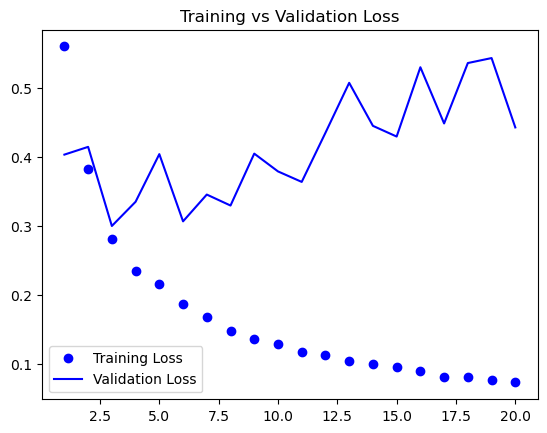

In [24]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 21)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

It performs slightly better than the regular LSTM. It also seems to overfit more quickly, which is unsurprising because a bidirectional layer has twice as many parameters as a chronological LSTM.

In [25]:
### Training and evaluating a bidirectional GRU on temperature timeseries data
from keras.models import Sequential
from keras import layers
from keras.optimizers import RMSprop

model = Sequential()
model.add(layers.Bidirectional(layers.GRU(32), input_shape=(None, float_data.shape[-1])))
model.add(layers.Dense(1))

model.compile(optimizer=RMSprop(), loss='mae')
history = model.fit(train_gen,
                    steps_per_epoch=500,
                    epochs=20,
                    validation_data=val_gen,
                    validation_steps = val_steps)

Epoch 1/20
500/500 [==============================] - 1773s 4s/step - loss: 0.2999 - val_loss: 0.2756
Epoch 2/20
500/500 [==============================] - 1719s 3s/step - loss: 0.2806 - val_loss: 0.2688
Epoch 3/20
500/500 [==============================] - 1868s 4s/step - loss: 0.2774 - val_loss: 0.2732
Epoch 4/20
500/500 [==============================] - 1906s 4s/step - loss: 0.2707 - val_loss: 0.2661
Epoch 5/20
500/500 [==============================] - 1739s 3s/step - loss: 0.2652 - val_loss: 0.2711
Epoch 6/20
500/500 [==============================] - 1794s 4s/step - loss: 0.2640 - val_loss: 0.2660
Epoch 7/20
500/500 [==============================] - 1776s 4s/step - loss: 0.2599 - val_loss: 0.2643
Epoch 8/20
500/500 [==============================] - 1737s 3s/step - loss: 0.2572 - val_loss: 0.2657
Epoch 9/20
500/500 [==============================] - 1694s 3s/step - loss: 0.2507 - val_loss: 0.2681
Epoch 10/20
500/500 [==============================] - 1693s 3s/step - loss: 0.247

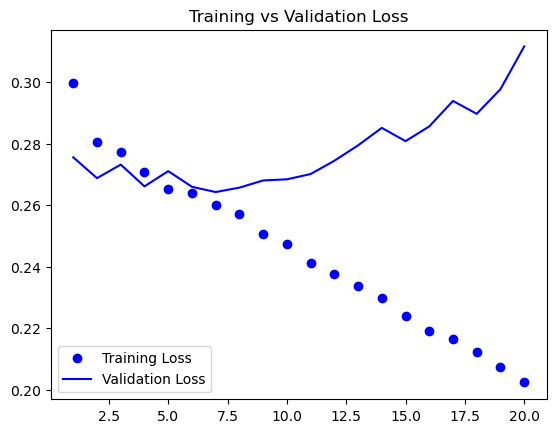

In [26]:

import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 21)




plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

This performs about as well as the regular GRU layer. It's easy to understand why: all the predictive capacity must come from the chronological half of the network, because the antichronological half is known to be severely underperforming on this task (again, because the recent past matters much more than the distant past in this case).